In [57]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

In [63]:
import pandas as pd
import numpy as np

# ==========================================
# 1. CARGA Y PREPARACIÓN DE AMBOS DATASETS
# ==========================================
ruta_tareas = "/content/historial_cambios (50).csv"
ruta_impuestos = "/content/drive/MyDrive/Prophet_Activity/datasets/fechas_impuestos (1).csv"  # <- Tu nuevo dataset

try:
    df_tareas = pd.read_csv(ruta_tareas)
    df_impuestos = pd.read_csv(ruta_impuestos)
except FileNotFoundError as e:
    print(f"⚠️ Error al cargar los archivos: {e}")
    print("Asegúrate de subir ambos archivos a la carpeta /content/ de Colab.")
    exit()

# --- FUNCIÓN DE LIMPIEZA PARA CAMPOS MULTIVALOR (CON COMAS) ---
def limpiar_fecha_multivalor(columna, formato='%d/%m/%Y'):
    col_str = columna.astype(str).str.strip()
    col_limpia = col_str.str.split(',').str[0].str.strip()
    col_limpia = col_limpia.replace(['nan', 'NaN', ''], np.nan)
    return pd.to_datetime(col_limpia, format=formato, errors='coerce')

# --- 1.A. PROCESAMIENTO DEL DATASET DE IMPUESTOS ---
# Adaptamos las columnas a los nombres de tu nuevo dataset
df_impuestos['Fecha_Limpia'] = limpiar_fecha_multivalor(df_impuestos['Fecha'])
# Filtramos y ordenamos para extraer el Calendario Maestro Único
calendario_vencimientos = sorted(df_impuestos['Fecha_Limpia'].dropna().unique())

# --- 1.B. PROCESAMIENTO DEL DATASET DE TAREAS ---
if df_tareas['fecha_modificacion'].dtype == 'object':
    df_tareas['fecha_modificacion'] = df_tareas['fecha_modificacion'].str.replace('.', '', regex=False).str.upper()

df_tareas['fecha_modificacion'] = pd.to_datetime(df_tareas['fecha_modificacion'], format='%d/%m/%Y, %I:%M:%S %p', errors='coerce')

en_blanco = df_tareas['fecha_modificacion'].isna()
if en_blanco.any():
    df_tareas.loc[en_blanco, 'fecha_modificacion'] = pd.to_datetime(df_tareas.loc[en_blanco, 'fecha_modificacion'], format='mixed', errors='coerce')

df_tareas = df_tareas.dropna(subset=['fecha_modificacion'])
df_tareas['fecha'] = df_tareas['fecha_modificacion'].dt.date

# Procesamiento de dummies para tipos de cambios
df_con_dummies = pd.get_dummies(df_tareas, columns=['tipo_cambio'], prefix='tipo')
columnas_tipo = [col for col in df_con_dummies.columns if col.startswith('tipo_')]

# Agrupación base por día
serie_temporal = df_con_dummies.groupby('fecha').agg(
    total_tareas=('fecha_modificacion', 'count'),
    usuarios_activos=('nombre_historial', 'nunique')
).reset_index()

tabla_tipos = df_con_dummies.groupby('fecha')[columnas_tipo].sum().reset_index()
serie_temporal = pd.merge(serie_temporal, tabla_tipos, on='fecha')

serie_temporal['fecha'] = pd.to_datetime(serie_temporal['fecha'])
serie_temporal = serie_temporal.sort_values('fecha').reset_index(drop=True)

In [64]:
# ==========================================
# 2. INGENIERÍA DE CARACTERÍSTICAS (Feature Engineering)
# ==========================================
serie_temporal['dia_semana'] = serie_temporal['fecha'].dt.dayofweek
serie_temporal['dia_mes'] = serie_temporal['fecha'].dt.day
serie_temporal['es_sabado'] = (serie_temporal['dia_semana'] == 5).astype(int)
serie_temporal['es_domingo'] = (serie_temporal['dia_semana'] == 6).astype(int)
serie_temporal['es_inicio_mes'] = (serie_temporal['dia_mes'] <= 5).astype(int)

# --- CRUCE AUTOMÁTICO CON EL CALENDARIO DE IMPUESTOS ---
def calcular_distancia_vencimiento(fecha_evaluada, lista_vencimientos):
    # Encontrar los vencimientos futuros o iguales a la fecha evaluada
    futuros = [v for v in lista_vencimientos if v >= fecha_evaluada]
    if futuros:
        proximo = min(futuros)
        return (proximo - fecha_evaluada).days
    return 999  # Valor neutral si no hay más vencimientos en el horizonte

# Aplicar la lógica fila por fila en el histórico pasado
serie_temporal['dias_para_vencimiento'] = serie_temporal['fecha'].apply(
    lambda x: calcular_distancia_vencimiento(x, calendario_vencimientos)
)

# Ventana de presión crítica (0 a 5 días de distancia del impuesto)
serie_temporal['presion_vencimiento'] = ((serie_temporal['dias_para_vencimiento'] >= 0) &
                                         (serie_temporal['dias_para_vencimiento'] <= 5)).astype(int)

# Lags y Ventanas Móviles Estables
serie_temporal['tareas_ayer'] = serie_temporal['total_tareas'].shift(1)
serie_temporal['tareas_hace_7d'] = serie_temporal['total_tareas'].shift(7)
serie_temporal['media_movil_7d'] = serie_temporal['total_tareas'].shift(1).rolling(window=7).mean()

serie_temporal = serie_temporal.dropna().reset_index(drop=True)

# Definición de Predictores para el Random Forest
features_base = [
    'dia_semana', 'dia_mes', 'es_sabado', 'es_domingo', 'es_inicio_mes',
    'dias_para_vencimiento', 'presion_vencimiento',
    'tareas_ayer', 'tareas_hace_7d', 'media_movil_7d', 'usuarios_activos'
]
X_columnas = features_base + columnas_tipo

X = serie_temporal[X_columnas]
y = serie_temporal['total_tareas']

def calcular_wmape(y_real, y_pred):
    sum_real = np.sum(y_real)
    if sum_real == 0: return 0.0
    return np.sum(np.abs(y_real - y_pred)) / sum_real

# ==========================================
# 2.5 EVALUACIÓN ESTRICTA (División Temporal)
# ==========================================
dias_test = 7

if len(serie_temporal) > dias_test * 2:
    X_train, X_test = X.iloc[:-dias_test], X.iloc[-dias_test:]
    y_train, y_test = y.iloc[:-dias_test], y.iloc[-dias_test:]

    modelo_evaluacion = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
    modelo_evaluacion.fit(X_train, y_train)
    y_pred_test = np.clip(modelo_evaluacion.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    wmape = calcular_wmape(y_test, y_pred_test)
    precision_ajustada = max(0, 100 - (wmape * 100))

    serie_temporal.loc[serie_temporal.index[-dias_test:], 'prediccion_test'] = y_pred_test
else:
    mae, rmse, wmape, precision_ajustada = None, None, None, None

In [65]:
# ==========================================
# 3. ENTRENAMIENTO EN PRODUCCIÓN (Modelo Final)
# ==========================================
modelo_futuro = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=6)
modelo_futuro.fit(X, y)

RandomForestRegressor(max_depth=6, random_state=42)

In [66]:
# ==========================================
# 4. PREDICCIÓN RECURSIVA CON CONTEXTO FISCAL AUTOMÁTICO
# ==========================================
ultima_fecha = serie_temporal['fecha'].max()
historial_valores = list(serie_temporal['total_tareas'])

perfil_usuarios = serie_temporal.groupby('dia_semana')['usuarios_activos'].mean().to_dict()
perfil_tipos = {col: serie_temporal.groupby('dia_semana')[col].mean().to_dict() for col in columnas_tipo}

futuras_fechas = []
predicciones_futuras = []

for i in range(1, 8):
    nueva_fecha = ultima_fecha + pd.Timedelta(days=i)
    n_dia_semana = nueva_fecha.dayofweek
    n_dia_mes = nueva_fecha.day

    n_es_sabado = 1 if n_dia_semana == 5 else 0
    n_es_domingo = 1 if n_dia_semana == 6 else 0
    n_es_inicio_mes = 1 if n_dia_mes <= 5 else 0

    # EL MOTOR BUSCA EN TU DATASET DE IMPUESTOS AUTOMÁTICAMENTE:
    n_dias_para_vencimiento = calcular_distancia_vencimiento(nueva_fecha, calendario_vencimientos)
    n_presion_vencimiento = 1 if (0 <= n_dias_para_vencimiento <= 5) else 0

    # Lags recursivos basados en predicciones previas
    lag_1 = historial_valores[-1]
    lag_7 = historial_valores[-7]
    movil_7d = np.mean(historial_valores[-7:])

    n_usuarios = int(round(perfil_usuarios.get(n_dia_semana, 1)))

    dict_entrada = {
        'dia_semana': n_dia_semana,
        'dia_mes': n_dia_mes,
        'es_sabado': n_es_sabado,
        'es_domingo': n_es_domingo,
        'es_inicio_mes': n_es_inicio_mes,
        'dias_para_vencimiento': n_dias_para_vencimiento,
        'presion_vencimiento': n_presion_vencimiento,
        'tareas_ayer': lag_1,
        'tareas_hace_7d': lag_7,
        'media_movil_7d': movil_7d,
        'usuarios_activos': n_usuarios
    }

    for col in columnas_tipo:
        dict_entrada[col] = perfil_tipos[col].get(n_dia_semana, 0)

    entrada_prediccion = pd.DataFrame([dict_entrada])[X_columnas]
    prediccion = max(0, int(round(modelo_futuro.predict(entrada_prediccion)[0])))

    futuras_fechas.append(nueva_fecha)
    predicciones_futuras.append(prediccion)
    historial_valores.append(prediccion)

df_futuro = pd.DataFrame({'fecha': futuras_fechas, 'pronostico': predicciones_futuras})

# ==========================================
# REPORTES Y IMPRESIÓN
# ==========================================
print("\n📊 REPORTE DE CALIFICACIÓN DEL MODELO CON CONTEXTO TRIBUTARIO AUTOMÁTICO:")
print("-" * 65)
if mae is not None:
    print(f"• Error Absoluto Medio (MAE):         {mae:.2f} tareas")
    print(f"• Raíz del Error Cuadrático (RMSE):   {rmse:.2f} tareas")
    print(f"• Error Porcentual Ponderado (wMAPE): {wmape * 100:.2f}%")
    print(f"• Precisión General Ajustada:         {precision_ajustada:.2f}%")
print("-" * 65)

print("\n📈 PRONÓSTICO DE CARGA DE TRABAJO AUTOMATIZADO (PRÓXIMOS 7 DÍAS REALES):")
for f, p in zip(futuras_fechas, predicciones_futuras):
    print(f"Fecha: {f.strftime('%Y-%m-%d')} -> Tareas estimadas: {p}")


📊 REPORTE DE CALIFICACIÓN DEL MODELO CON CONTEXTO TRIBUTARIO AUTOMÁTICO:
-----------------------------------------------------------------
• Error Absoluto Medio (MAE):         8.12 tareas
• Raíz del Error Cuadrático (RMSE):   10.16 tareas
• Error Porcentual Ponderado (wMAPE): 41.79%
• Precisión General Ajustada:         58.21%
-----------------------------------------------------------------

📈 PRONÓSTICO DE CARGA DE TRABAJO AUTOMATIZADO (PRÓXIMOS 7 DÍAS REALES):
Fecha: 2026-07-11 -> Tareas estimadas: 5
Fecha: 2026-07-12 -> Tareas estimadas: 5
Fecha: 2026-07-13 -> Tareas estimadas: 32
Fecha: 2026-07-14 -> Tareas estimadas: 22
Fecha: 2026-07-15 -> Tareas estimadas: 24
Fecha: 2026-07-16 -> Tareas estimadas: 21
Fecha: 2026-07-17 -> Tareas estimadas: 16


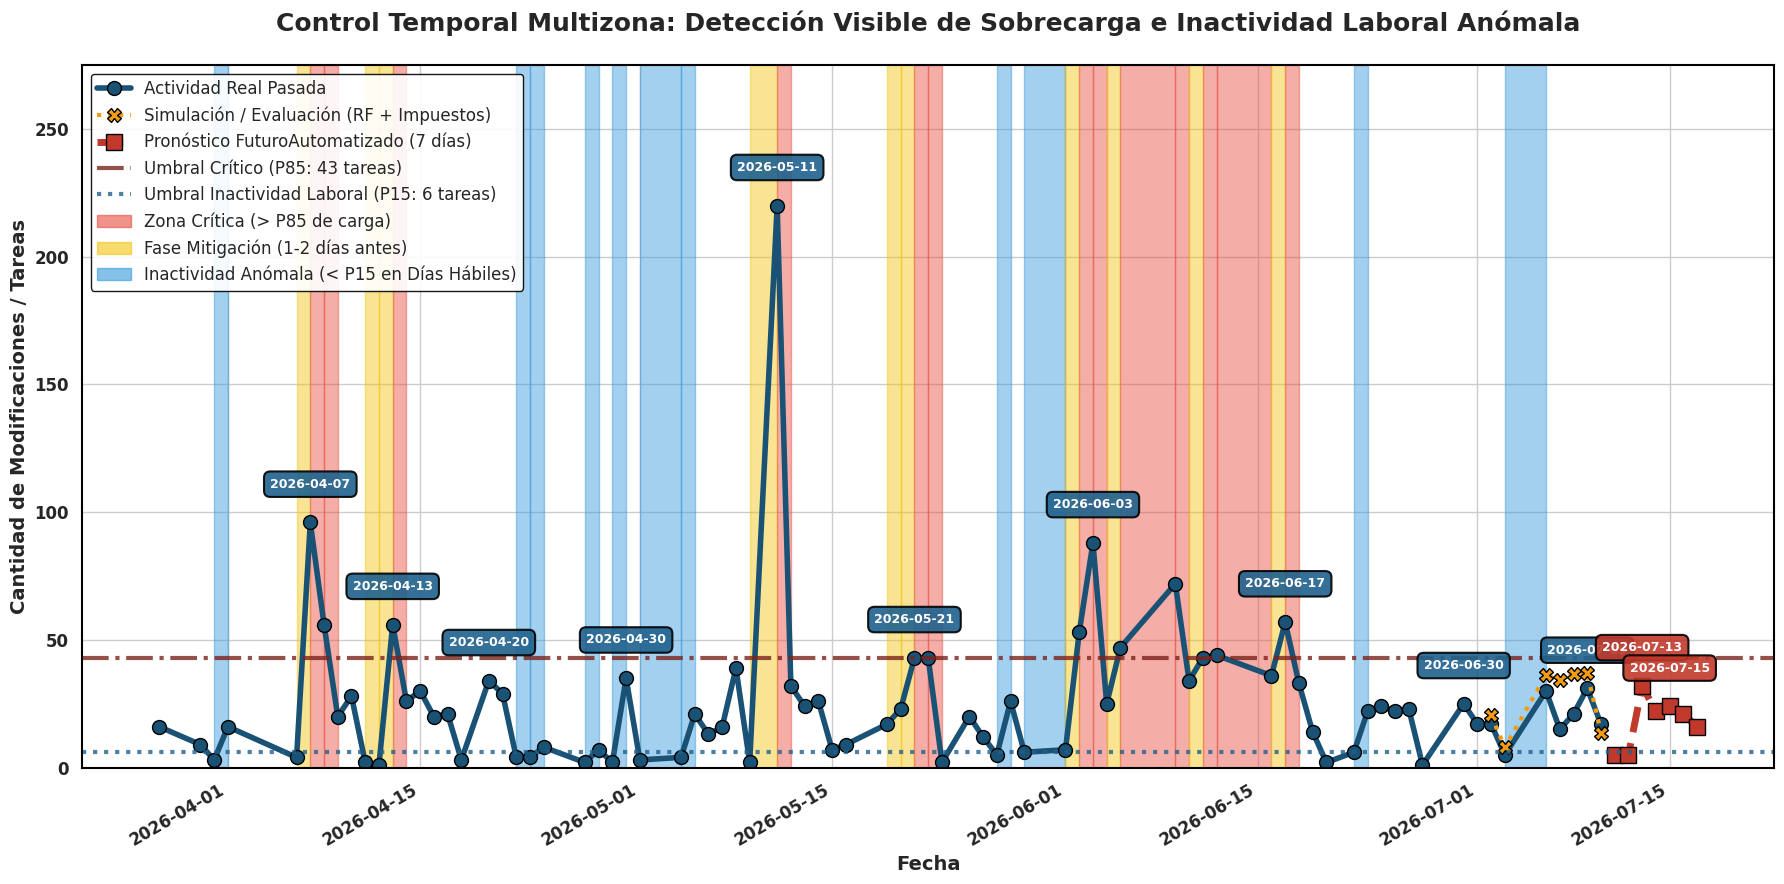

In [67]:
# ==========================================
# 5. GRÁFICA DE RENDIMIENTO ALTAMENTE VISIBLE (DOBLE ALERTA)
# ==========================================
import matplotlib.patches as mpatches

# Aumentar el tamaño general de la figura para mayor visibilidad
plt.figure(figsize=(18, 9))
# Usar un estilo limpio con cuadrícula para mayor legibilidad
sns.set_theme(style="whitegrid", rc={"axes.linewidth": 1.5, "axes.edgecolor": "black"})

# --- 1. DEFINICIÓN ESTADÍSTICA DE CARGA CRÍTICA (ALTA) ---
# Usamos el percentil 85 de los datos históricos
umbral_critico = serie_temporal['total_tareas'].quantile(0.85)

# --- 2. DEFINICIÓN ESTADÍSTICA DE INACTIVIDAD ANÓMALA (BAJA INTELIGENTE) ---
# Filtramos los fines de semana (sábado=5, domingo=6) para calcular el umbral real en días hábiles
dias_habiles = serie_temporal[~serie_temporal['fecha'].dt.dayofweek.isin([5, 6])]
umbral_baja_actividad = dias_habiles['total_tareas'].quantile(0.15)

# Unir histórico y futuro en una línea de tiempo continua para buscar las alertas
fechas_totales = pd.concat([serie_temporal['fecha'], df_futuro['fecha']]).reset_index(drop=True)
valores_totales = pd.concat([serie_temporal['total_tareas'], df_futuro['pronostico']]).reset_index(drop=True)

# Identificar cuáles índices exactos son críticos (Altos)
indices_criticos = valores_totales[valores_totales >= umbral_critico].index
fechas_criticas = set(fechas_totales.iloc[indices_criticos])

# Identificar las zonas de detección previa (2 días antes de cualquier fecha crítica)
fechas_previa_alerta = set()
for f_critica in fechas_criticas:
    for delta in range(1, 3):  # 1 y 2 días antes
        fecha_antes = f_critica - pd.Timedelta(days=delta)
        if fecha_antes not in fechas_criticas:
            fechas_previa_alerta.add(fecha_antes)

# Identificar índices de inactividad anómala (Solo en días hábiles de lunes a viernes)
fechas_baja_actividad = set()
for idx, fecha in fechas_totales.items():
    # dayofweek < 5 significa Lunes a Viernes
    if fecha.dayofweek < 5 and valores_totales.iloc[idx] <= umbral_baja_actividad:
        fechas_baja_actividad.add(fecha)

# --- COLOREADO DINÁMICO DE BANDAS VERTICALES (AXVSPAN) CON MAYOR VISIBILIDAD ---
for i in range(len(fechas_totales) - 1):
    f_inicio = fechas_totales.iloc[i]
    f_fin = fechas_totales.iloc[i+1]

    # 1. Alerta Roja: Zona Crítica de alta carga (Color más intenso)
    if f_inicio in fechas_criticas:
        plt.axvspan(f_inicio, f_fin, color='#E74C3C', alpha=0.45, edgecolor=None)
    # 2. Alerta Amarilla: Fase de mitigación previa a la alta carga (Color más intenso)
    elif f_inicio in fechas_previa_alerta:
        plt.axvspan(f_inicio, f_fin, color='#F1C40F', alpha=0.45, edgecolor=None)
    # 3. Alerta Azul/Cian: Inactividad inusualmente baja (Color más intenso)
    elif f_inicio in fechas_baja_actividad:
        plt.axvspan(f_inicio, f_fin, color='#3498DB', alpha=0.45, edgecolor=None)

# --- DIBUJO DE LAS LÍNEAS PRINCIPALES CON MAYOR GROSOR Y TAMAÑO ---
plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'],
         label='Actividad Real Pasada', color='#1A5276', marker='o', linewidth=4, markersize=10, markeredgecolor='black')

if mae is not None:
    df_test_plot = serie_temporal.dropna(subset=['prediccion_test'])
    plt.plot(df_test_plot['fecha'], df_test_plot['prediccion_test'],
             label='Simulación / Evaluación (RF + Impuestos)', color='#F39C12', linestyle=':', marker='X', linewidth=3, markersize=10, markeredgecolor='black')

plt.plot(df_futuro['fecha'], df_futuro['pronostico'],
         label='Pronóstico FuturoAutomatizado (7 días)', color='#C0392B', linestyle='--', marker='s', linewidth=5, markersize=12, markeredgecolor='black')

# --- LÍNEAS DE CONTROL HORIZONTALES MÁS VISIBLES ---
plt.axhline(y=umbral_critico, color='#7B241C', linestyle='-.', linewidth=3, alpha=0.8,
            label=f'Umbral Crítico (P85: {int(umbral_critico)} tareas)')
plt.axhline(y=umbral_baja_actividad, color='#21618C', linestyle=':', linewidth=3, alpha=0.8,
            label=f'Umbral Inactividad Laboral (P15: {int(umbral_baja_actividad)} tareas)')

# --- ETIQUETADO DE PICOS Y ANOMALÍAS DE BAJA MÁS GRANDES Y LEGIBLES ---
# Etiquetado de Picos Históricos
picos_hist, _ = find_peaks(serie_temporal['total_tareas'], distance=5, prominence=2)
for idx in picos_hist:
    fecha_pico = serie_temporal['fecha'].iloc[idx]
    valor_pico = serie_temporal['total_tareas'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 25),
                 textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#FFFFFF',
                 bbox=dict(boxstyle="round,pad=0.5", fc="#1F618D", ec="black", lw=1.5, alpha=0.9))

# Etiquetado de Picos Futuros Proyectados
picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1, prominence=2)
for idx in picos_fut:
    fecha_pico = df_futuro['fecha'].iloc[idx]
    valor_pico = df_futuro['pronostico'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 25),
                 textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#FFFFFF',
                 bbox=dict(boxstyle="round,pad=0.5", fc="#C0392B", ec="black", lw=1.5, alpha=0.9))

# Etiquetas de advertencia predictiva para días de baja actividad en el pronóstico
for f, p in zip(df_futuro['fecha'], df_futuro['pronostico']):
    if f in fechas_baja_actividad:
        plt.annotate('¡ALERTA BAJA!', xy=(f, p), xytext=(0, -30),
                     textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#FFFFFF',
                     bbox=dict(boxstyle="round,pad=0.5", fc="#2980B9", ec="black", lw=1.5, alpha=0.9))

# --- CONFIGURACIÓN DE LEYENDAS Y ESTÉTICA PARA ALTA VISIBILIDAD ---
# Creamos parches personalizados con colores más intensos
parche_critico = mpatches.Patch(color='#E74C3C', alpha=0.6, label='Zona Crítica (> P85 de carga)')
parche_prevencion = mpatches.Patch(color='#F1C40F', alpha=0.6, label='Fase Mitigación (1-2 días antes)')
parche_baja = mpatches.Patch(color='#3498DB', alpha=0.6, label='Inactividad Anómala (< P15 en Días Hábiles)')

handles, labels = plt.gca().get_legend_handles_labels()
# Añadir parches conceptuales a la leyenda, con un orden claro
handles.extend([parche_critico, parche_prevencion, parche_baja])

plt.title('Control Temporal Multizona: Detección Visible de Sobrecarga e Inactividad Laboral Anómala', fontsize=18, weight='bold', pad=25)
plt.xlabel('Fecha', fontsize=14, weight='bold')
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=14, weight='bold')

# Aumentar tamaño de etiquetas en los ejes
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')

plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.25)
plt.gcf().autofmt_xdate()

# Leyenda más grande y prominentemente ubicada
plt.legend(handles=handles, fontsize=12, loc='upper left', frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

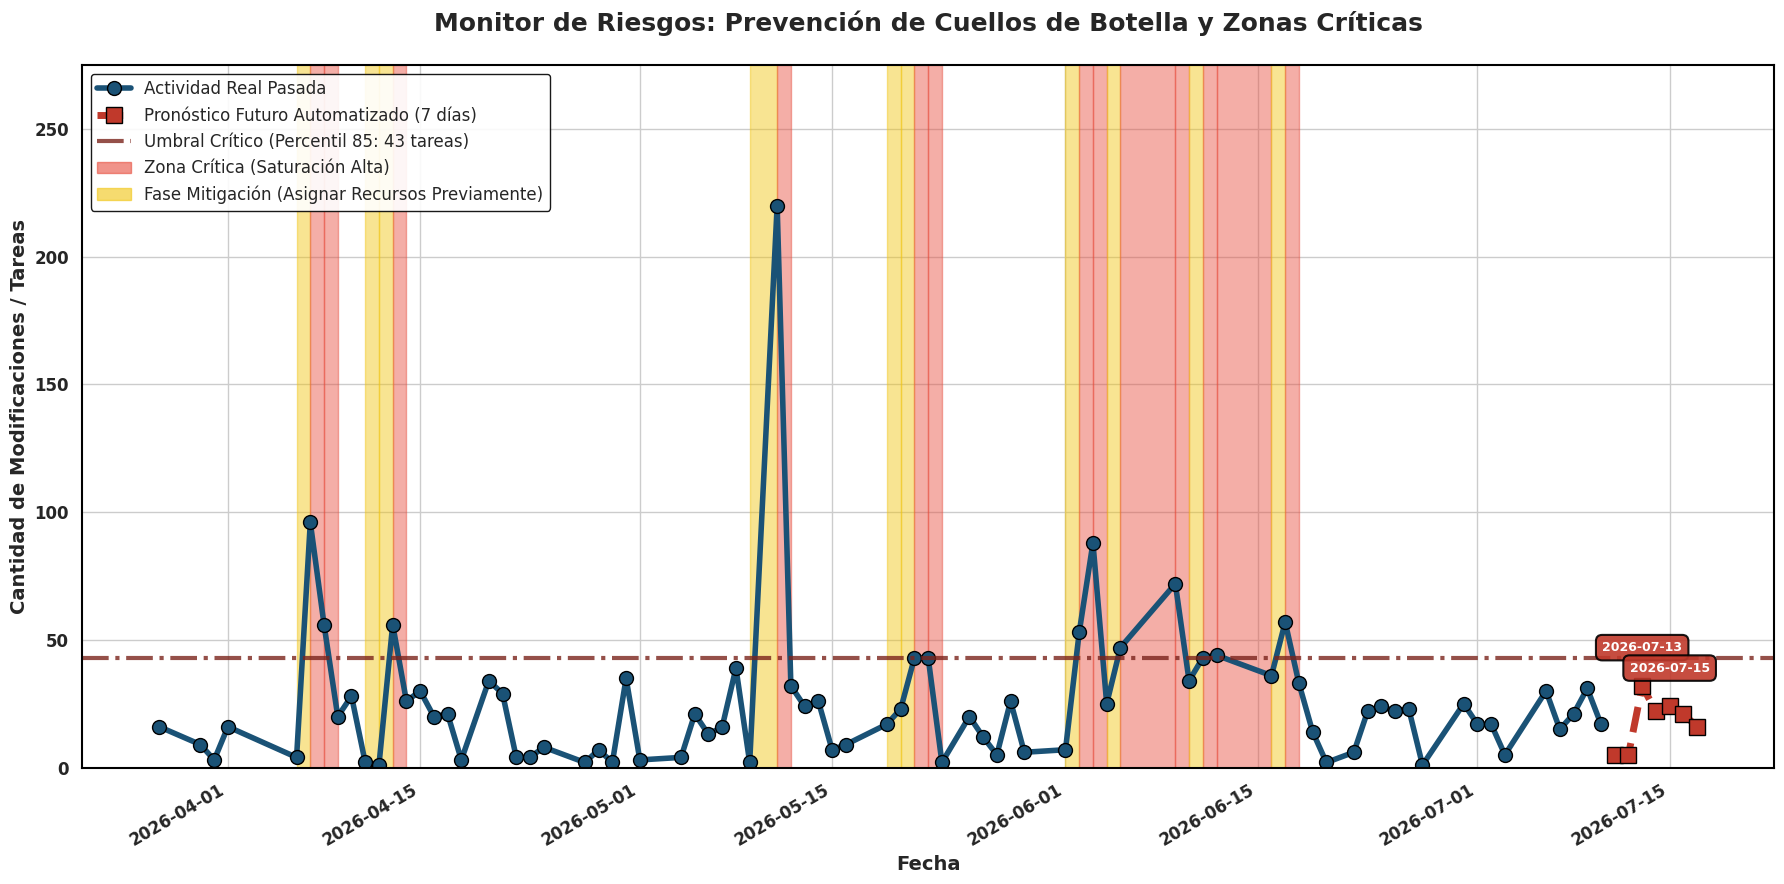

In [68]:
# ==============================================================================
# VISTA 2: MONITOR DE SOBRECARGA LABORAL (Umbral Crítico)
# ==============================================================================
plt.figure(figsize=(18, 9))
sns.set_theme(style="whitegrid", rc={"axes.linewidth": 1.5, "axes.edgecolor": "black"})

# Umbral Crítico basado en percentil 85 histórico
umbral_critico = serie_temporal['total_tareas'].quantile(0.85)

fechas_totales = pd.concat([serie_temporal['fecha'], df_futuro['fecha']]).reset_index(drop=True)
valores_totales = pd.concat([serie_temporal['total_tareas'], df_futuro['pronostico']]).reset_index(drop=True)

fechas_criticas = set(fechas_totales.iloc[valores_totales[valores_totales >= umbral_critico].index])

fechas_previa_alerta = set()
for f_critica in fechas_criticas:
    for delta in range(1, 3):
        fecha_antes = f_critica - pd.Timedelta(days=delta)
        if fecha_antes not in fechas_criticas:
            fechas_previa_alerta.add(fecha_antes)

# Sombreados verticales: Solo zonas críticas (Rojo) y Mitigación (Amarillo)
for i in range(len(fechas_totales) - 1):
    f_inicio, f_fin = fechas_totales.iloc[i], fechas_totales.iloc[i+1]
    if f_inicio in fechas_criticas:
        plt.axvspan(f_inicio, f_fin, color='#E74C3C', alpha=0.45)
    elif f_inicio in fechas_previa_alerta:
        plt.axvspan(f_inicio, f_fin, color='#F1C40F', alpha=0.45)

# Trazado de líneas principales
plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#1A5276', marker='o', linewidth=4, markersize=10, markeredgecolor='black')
plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Automatizado (7 días)', color='#C0392B', linestyle='--', marker='s', linewidth=5, markersize=12, markeredgecolor='black')

# Línea horizontal indicando visualmente dónde empieza el umbral estadístico de peligro
plt.axhline(y=umbral_critico, color='#7B241C', linestyle='-.', linewidth=3, alpha=0.8, label=f'Umbral Crítico (Percentil 85: {int(umbral_critico)} tareas)')

# Etiquetado de Picos Futuros Proyectados
picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1, prominence=2)
for idx in picos_fut:
    f_pico = df_futuro['fecha'].iloc[idx]
    v_pico = df_futuro['pronostico'].iloc[idx]
    plt.annotate(f_pico.strftime('%Y-%m-%d'), xy=(f_pico, v_pico), xytext=(0, 25), textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#FFFFFF', bbox=dict(boxstyle="round,pad=0.5", fc="#C0392B", ec="black", lw=1.5, alpha=0.9))

parche_critico = mpatches.Patch(color='#E74C3C', alpha=0.6, label='Zona Crítica (Saturación Alta)')
parche_prevencion = mpatches.Patch(color='#F1C40F', alpha=0.6, label='Fase Mitigación (Asignar Recursos Previamente)')

handles, labels = plt.gca().get_legend_handles_labels()
handles.extend([parche_critico, parche_prevencion])

plt.title('Monitor de Riesgos: Prevención de Cuellos de Botella y Zonas Críticas', fontsize=18, weight='bold', pad=25)
plt.xlabel('Fecha', fontsize=14, weight='bold')
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=14, weight='bold')
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.25)
plt.gcf().autofmt_xdate()
plt.legend(handles=handles, fontsize=12, loc='upper left', frameon=True, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

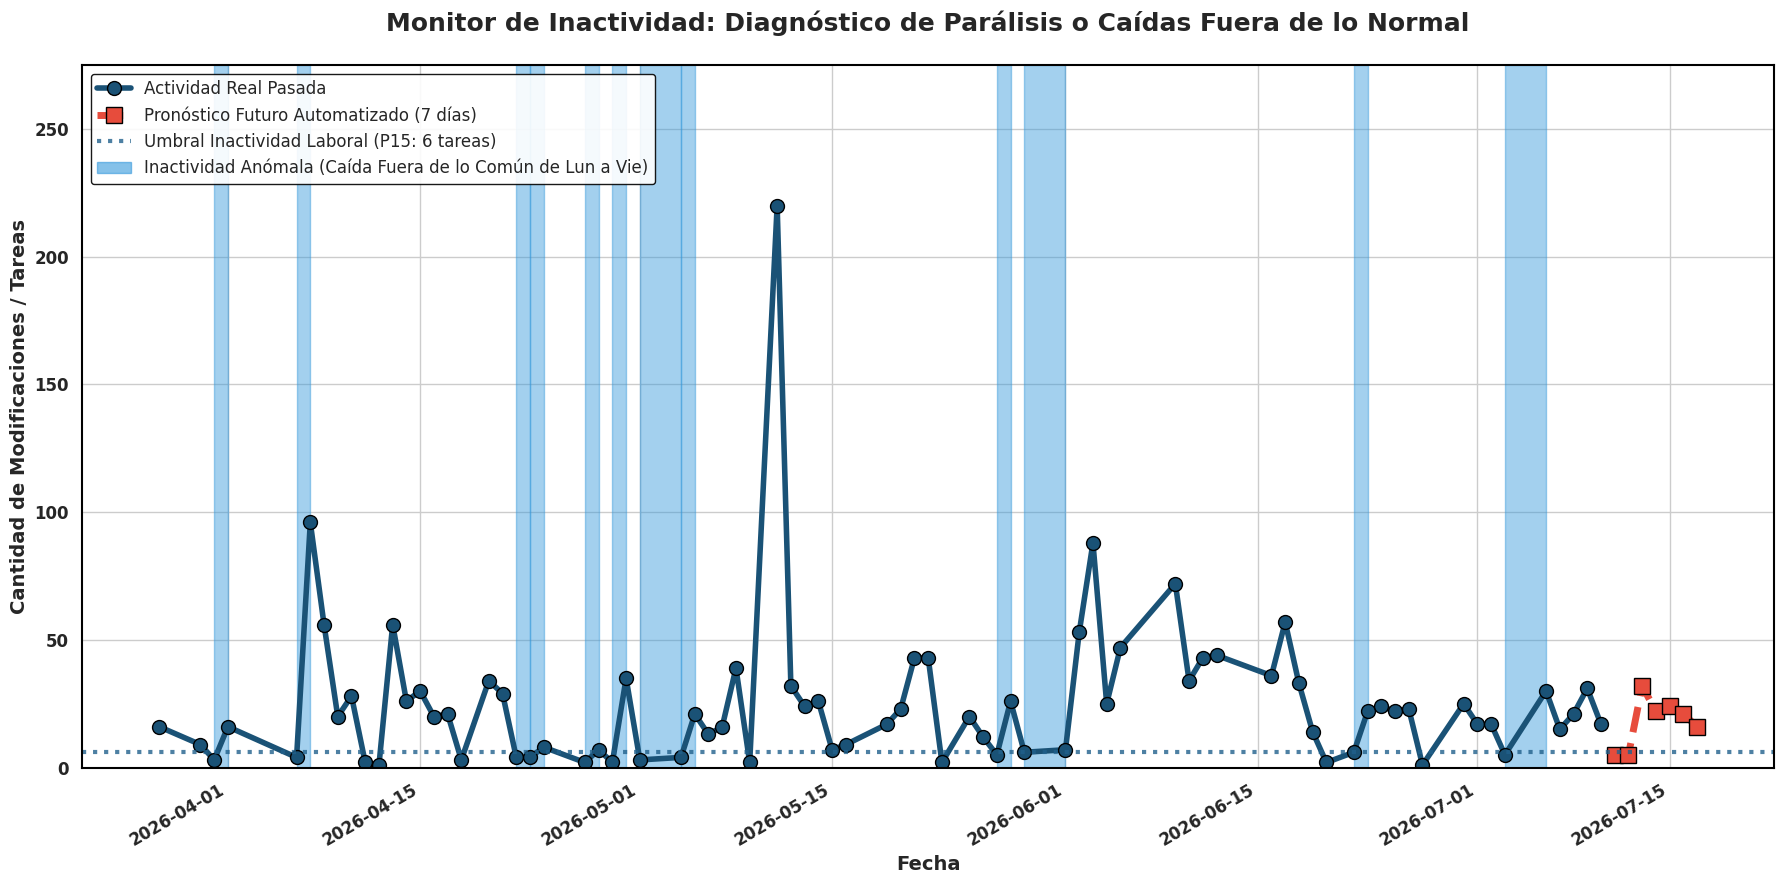

In [69]:
# ==============================================================================
# VISTA 3: DETECTOR DE INACTIVIDAD OPERATIVA ANÓMALA (Días Hábiles)
# ==============================================================================
plt.figure(figsize=(18, 9))
sns.set_theme(style="whitegrid", rc={"axes.linewidth": 1.5, "axes.edgecolor": "black"})

# Extraemos solo lunes a viernes de la historia para fijar un suelo realista
dias_habiles = serie_temporal[~serie_temporal['fecha'].dt.dayofweek.isin([5, 6])]
umbral_baja_actividad = dias_habiles['total_tareas'].quantile(0.15)

fechas_totales = pd.concat([serie_temporal['fecha'], df_futuro['fecha']]).reset_index(drop=True)
valores_totales = pd.concat([serie_temporal['total_tareas'], df_futuro['pronostico']]).reset_index(drop=True)

# Identificar caídas preocupantes que ocurran únicamente de lunes a viernes
fechas_baja_actividad = set()
for idx, fecha in fechas_totales.items():
    if fecha.dayofweek < 5 and valores_totales.iloc[idx] <= umbral_baja_actividad:
        fechas_baja_actividad.add(fecha)

# Sombreado vertical: Solo zonas de inactividad anómala (Azul/Cian)
for i in range(len(fechas_totales) - 1):
    f_inicio, f_fin = fechas_totales.iloc[i], fechas_totales.iloc[i+1]
    if f_inicio in fechas_baja_actividad:
        plt.axvspan(f_inicio, f_fin, color='#3498DB', alpha=0.45)

# Trazado de líneas principales
plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#1A5276', marker='o', linewidth=4, markersize=10, markeredgecolor='black')
plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Automatizado (7 días)', color='#E74C3C', linestyle='--', marker='s', linewidth=5, markersize=12, markeredgecolor='black')

# Línea de control inferior indicando la caída preocupante
plt.axhline(y=umbral_baja_actividad, color='#21618C', linestyle=':', linewidth=3, alpha=0.8, label=f'Umbral Inactividad Laboral (P15: {int(umbral_baja_actividad)} tareas)')

# Etiquetas específicas de "¡ALERTA BAJA!" en las proyecciones futuras afectadas
for f, p in zip(df_futuro['fecha'], df_futuro['pronostico']):
    if f in fechas_baja_actividad:
        plt.annotate('¡ALERTA BAJA!', xy=(f, p), xytext=(0, -30), textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#FFFFFF', bbox=dict(boxstyle="round,pad=0.5", fc="#2980B9", ec="black", lw=1.5, alpha=0.9))

parche_baja = mpatches.Patch(color='#3498DB', alpha=0.6, label='Inactividad Anómala (Caída Fuera de lo Común de Lun a Vie)')

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(parche_baja)

plt.title('Monitor de Inactividad: Diagnóstico de Parálisis o Caídas Fuera de lo Normal', fontsize=18, weight='bold', pad=25)
plt.xlabel('Fecha', fontsize=14, weight='bold')
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=14, weight='bold')
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.25)
plt.gcf().autofmt_xdate()
plt.legend(handles=handles, fontsize=12, loc='upper left', frameon=True, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

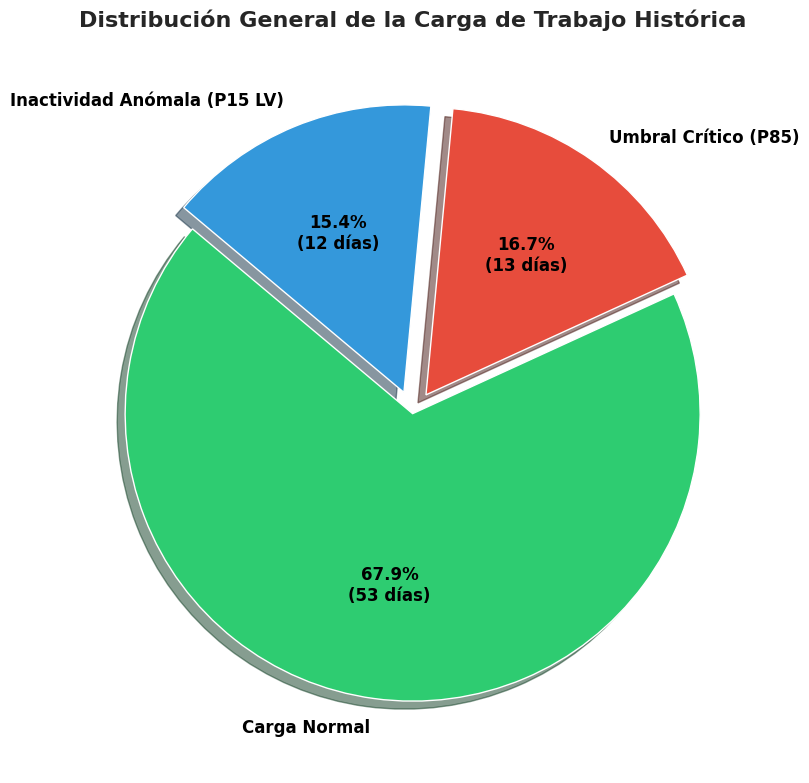

In [70]:
# ==============================================================================
# VISTA 4: DISTRIBUCIÓN PORCENTUAL OPERATIVA (Gráfico de Pastel)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Definición de umbrales idénticos a los gráficos anteriores
umbral_critico = serie_temporal['total_tareas'].quantile(0.85)
dias_habiles = serie_temporal[~serie_temporal['fecha'].dt.dayofweek.isin([5, 6])]
umbral_baja_actividad = dias_habiles['total_tareas'].quantile(0.15)

# 2. Clasificación de cada día del registro histórico
valores = serie_temporal['total_tareas'].values
fechas = serie_temporal['fecha']

cant_critico = 0
cant_inactividad = 0
cant_normal = 0

for fecha, valor in zip(fechas, valores):
    if valor >= umbral_critico:
        cant_critico += 1
    # Evaluamos inactividad solo si es día de semana (Lunes=0 a Viernes=4)
    elif fecha.dayofweek < 5 and valor <= umbral_baja_actividad:
        cant_inactividad += 1
    else:
        cant_normal += 1

# 3. Preparación de datos para el gráfico de pastel
categorias = ['Carga Normal', 'Umbral Crítico (P85)', 'Inactividad Anómala (P15 LV)']
cantidades = [cant_normal, cant_critico, cant_inactividad]
colores = ['#2ECC71', '#E74C3C', '#3498DB']  # Verde balanceado, Rojo crítico, Azul inactividad
# Resaltar ligeramente las porciones de anomalías (separarlas del centro)
desfase = (0, 0.08, 0.08)

# 4. Construcción del gráfico de alta visibilidad
plt.figure(figsize=(10, 8))

plt.pie(
    cantidades,
    explode=desfase,
    labels=categorias,
    colors=colores,
    autopct=lambda p: '{:.1f}%\n({:.0f} días)'.format(p, p * sum(cantidades) / 100),
    shadow=True,
    startangle=140,
    textprops={'fontsize': 12, 'weight': 'bold', 'color': 'black'}
)

# Estética y título limpio
plt.title('Distribución General de la Carga de Trabajo Histórica', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

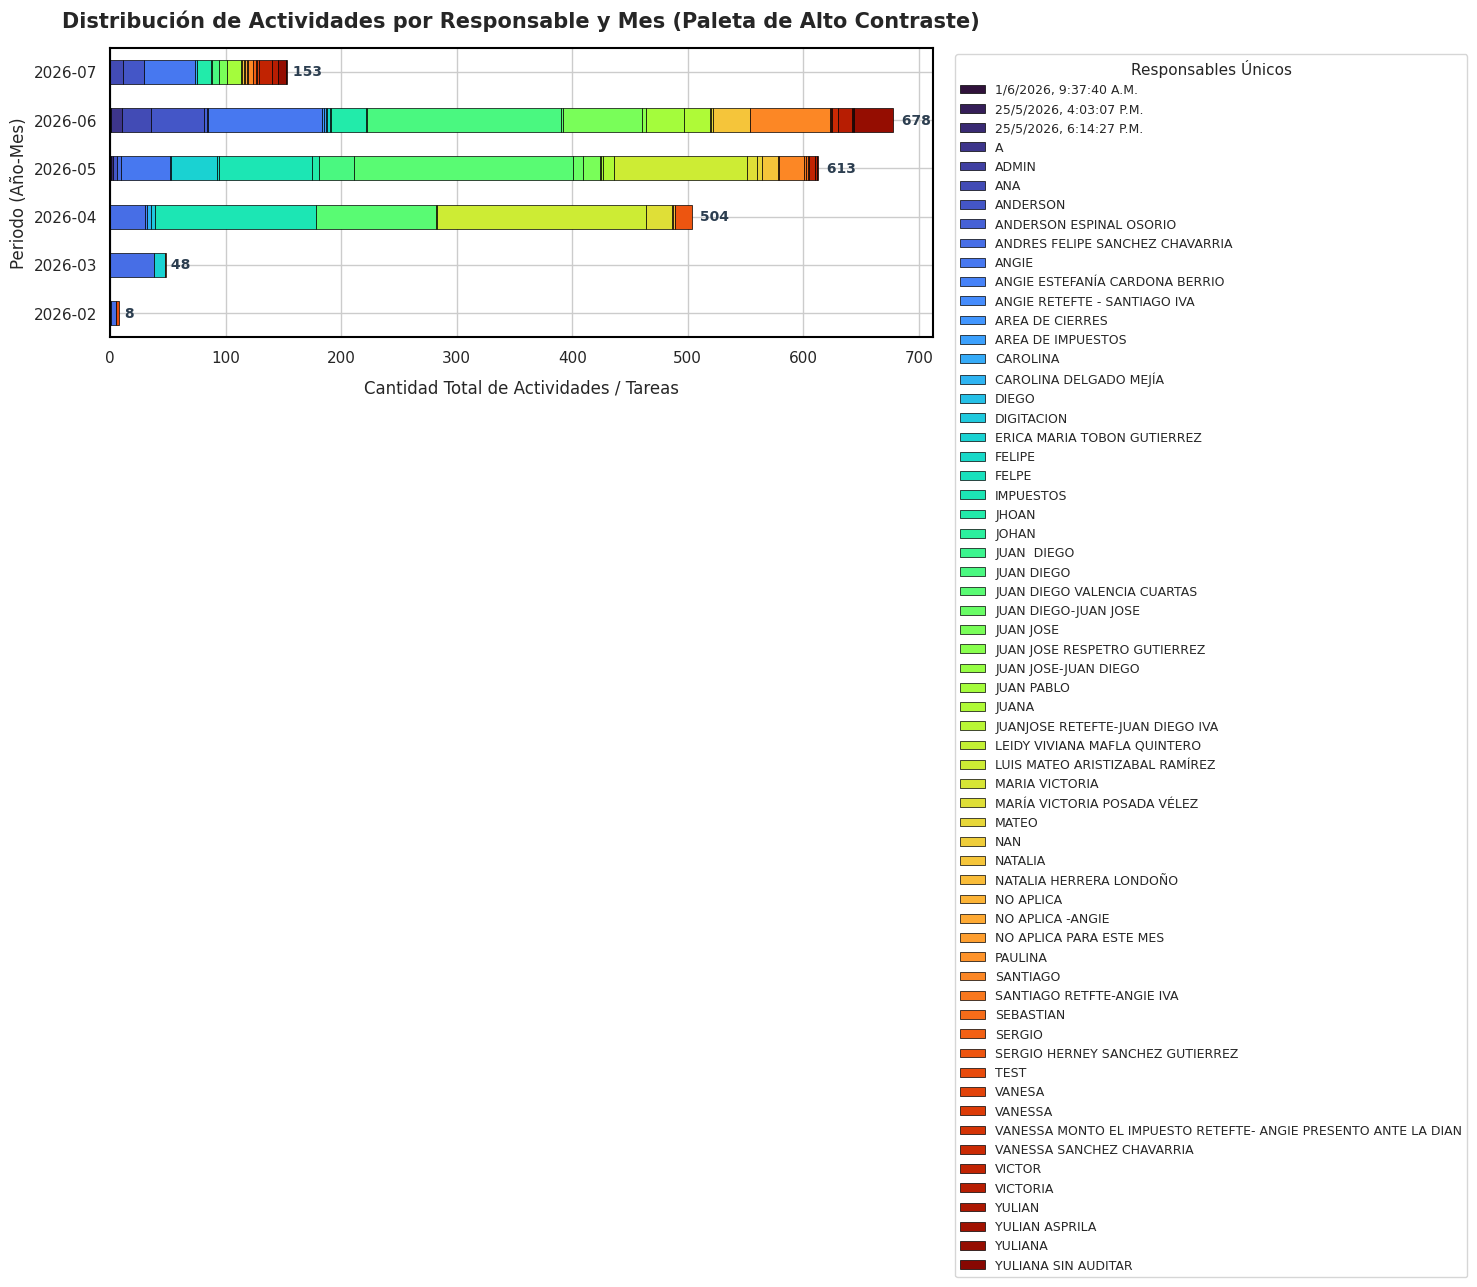

In [71]:
# ==========================================
# 6. NUEVO GRÁFICO: ACTIVIDAD POR RESPONSABLE Y MES (COLORES ÚNICOS Y CORREGIDOS)
# ==========================================
import matplotlib.cm as cm

columna_responsable = 'RESPONSABLE'  # Asegúrate de mapear la columna correcta

if columna_responsable in df_tareas.columns:

    # 1. Normalización estricta de nombres
    df_tareas[columna_responsable] = df_tareas[columna_responsable].astype(str).str.strip().str.upper()

    # 2. Extracción temporal
    df_tareas['año_mes'] = df_tareas['fecha_modificacion'].dt.to_period('M').astype(str)

    # 3. Agrupación y pivote estructurado
    df_responsables = df_tareas.groupby(['año_mes', columna_responsable]).size().reset_index(name='cantidad_actividades')
    df_pivot = df_responsables.pivot(index='año_mes', columns=columna_responsable, values='cantidad_actividades').fillna(0)

    # --- GENERACIÓN DE COLORES DE ALTO CONTRASTE ---
    # Contamos cuántos responsables reales e independientes quedaron
    num_responsables = len(df_pivot.columns)

    # Generamos una lista de colores distribuidos uniformemente a lo largo de un espectro amplio (Jet/Turbo/Nipy_spectral)
    # Esto evita la repetición cíclica de las paletas comunes
    colores_unicos = [cm.turbo(i / num_responsables) for i in range(num_responsables)]

    # 4. Configurar lienzo amplio
    fig, ax = plt.subplots(figsize=(15, 9))
    sns.set_theme(style="whitegrid")

    # 5. Graficar de forma horizontal (barras horizontales apiladas para mejor lectura de nombres)
    df_pivot.plot(kind='barh', stacked=True, ax=ax, color=colores_unicos, edgecolor='black', linewidth=0.5)

    # Personalización estética avanzada
    plt.title('Distribución de Actividades por Responsable y Mes (Paleta de Alto Contraste)', fontsize=15, weight='bold', pad=15)
    plt.xlabel('Cantidad Total de Actividades / Tareas', fontsize=12, labelpad=10)
    plt.ylabel('Periodo (Año-Mes)', fontsize=12)

    # Colocar la leyenda de forma lateral para que no tape las barras
    plt.legend(title='Responsables Únicos', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, title_fontsize=11, ncol=1)

    # Añadir el valor numérico total al final de cada barra mensual para referencia rápida
    totales_por_mes = df_pivot.sum(axis=1)
    for i, total in enumerate(totales_por_mes):
        if total > 0:
            ax.text(total + (total * 0.005), i, f' {int(total)}', va='center', ha='left', fontsize=10, weight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

else:
    print(f"\n⚠️ No se encontró la columna '{columna_responsable}'.")

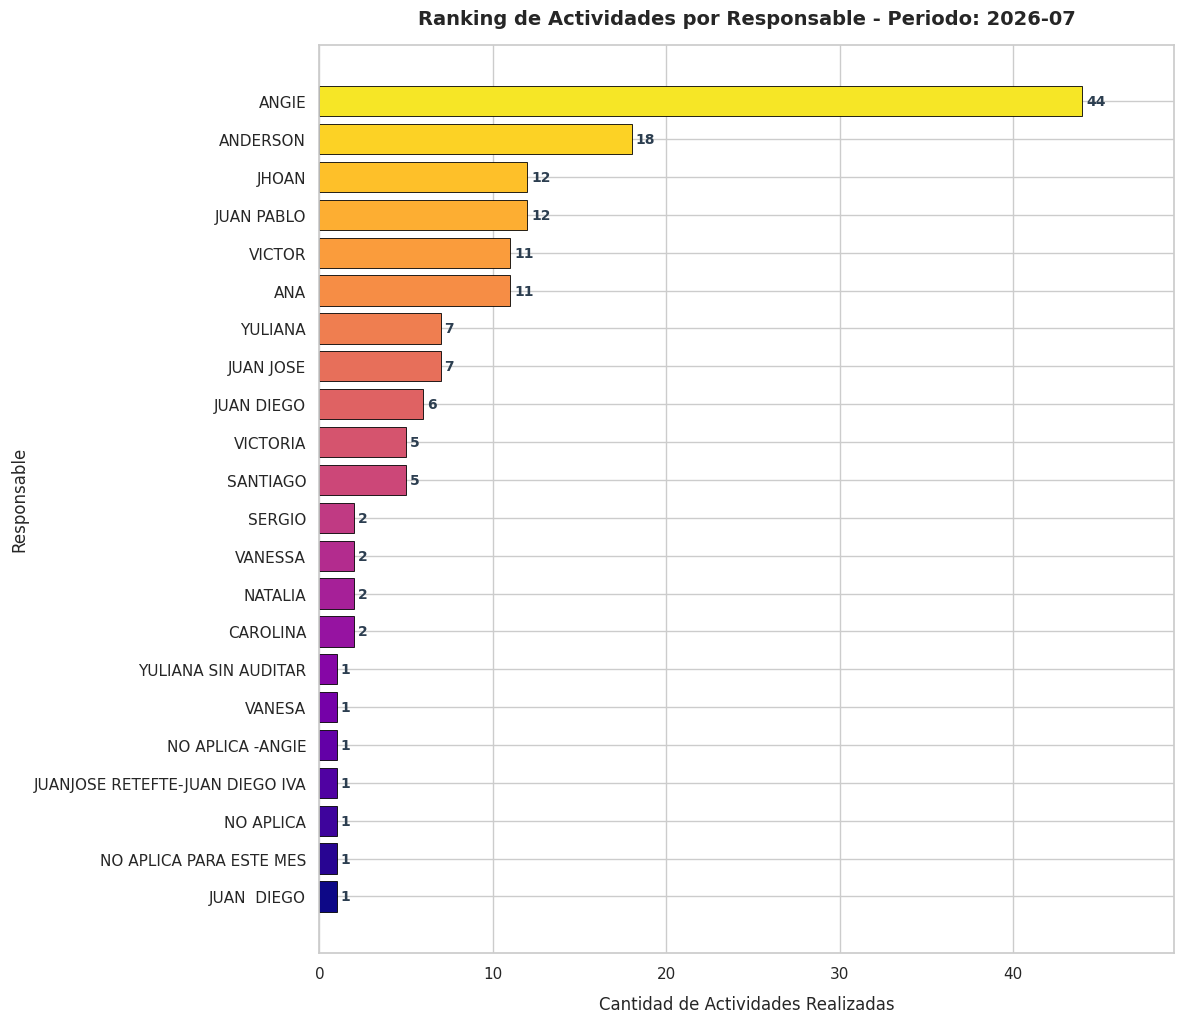

In [72]:
# ==========================================
# 7. GRÁFICO SÓLO DEL MES ACTUAL / ÚLTIMO MES
# ==========================================
import matplotlib.cm as cm

columna_responsable = 'RESPONSABLE'  # Mapea tu columna de responsables

if columna_responsable in df_tareas.columns:

    # 1. Normalización de nombres
    df_tareas[columna_responsable] = df_tareas[columna_responsable].astype(str).str.strip().str.upper()

    # 2. Asegurar campo año_mes y obtener el último mes disponible (mes actual en el dataset)
    df_tareas['año_mes'] = df_tareas['fecha_modificacion'].dt.to_period('M').astype(str)
    ultimo_mes = df_tareas['año_mes'].max()

    # 3. Filtrar el dataset únicamente para el mes actual
    df_mes_actual = df_tareas[df_tareas['año_mes'] == ultimo_mes]

    # 4. Agrupar, contar por responsable y ordenar de mayor a menor
    df_ranking = df_mes_actual.groupby(columna_responsable).size().reset_index(name='actividades')
    df_ranking = df_ranking.sort_values(by='actividades', ascending=True) # Ascendente para que el mayor quede arriba en el gráfico horizontal

    if not df_ranking.empty:
        # --- CONFIGURACIÓN DE COLORES DEGRADADOS ---
        num_elementos = len(df_ranking)
        # Genera un degradado estético para diferenciar los volúmenes de trabajo
        colores_degradado = [cm.plasma(i / num_elementos) for i in range(num_elementos)]

        # 5. Inicializar el lienzo
        plt.figure(figsize=(12, 6 + (num_elementos * 0.2))) # El alto se ajusta dinámicamente según la cantidad de personas
        sns.set_theme(style="whitegrid")

        # 6. Dibujar gráfico de barras horizontales sencillas
        barras = plt.barh(df_ranking[columna_responsable], df_ranking['actividades'],
                          color=colores_degradado, edgecolor='black', linewidth=0.6)

        # Personalización estética
        plt.title(f'Ranking de Actividades por Responsable - Periodo: {ultimo_mes}', fontsize=14, weight='bold', pad=15)
        plt.xlabel('Cantidad de Actividades Realizadas', fontsize=12, labelpad=10)
        plt.ylabel('Responsable', fontsize=12)

        # Ajustar el límite de X para que los números al final de la barra no se corten
        max_valor = df_ranking['actividades'].max()
        plt.xlim(0, max_valor * 1.12)

        # Añadir las etiquetas con el total exacto al final de cada barra
        for barra in barras:
            ancho = barra.get_width()
            plt.text(ancho + (max_valor * 0.005), barra.get_y() + barra.get_height()/2,
                     f'{int(ancho)}', va='center', ha='left', fontsize=10, weight='bold', color='#2c3e50')

        plt.tight_layout()
        plt.show()
    else:
        print(f"\n⚠️ No se encontraron datos para el periodo {ultimo_mes}.")
else:
    print(f"\n⚠️ La columna '{columna_responsable}' no existe en el dataset.")

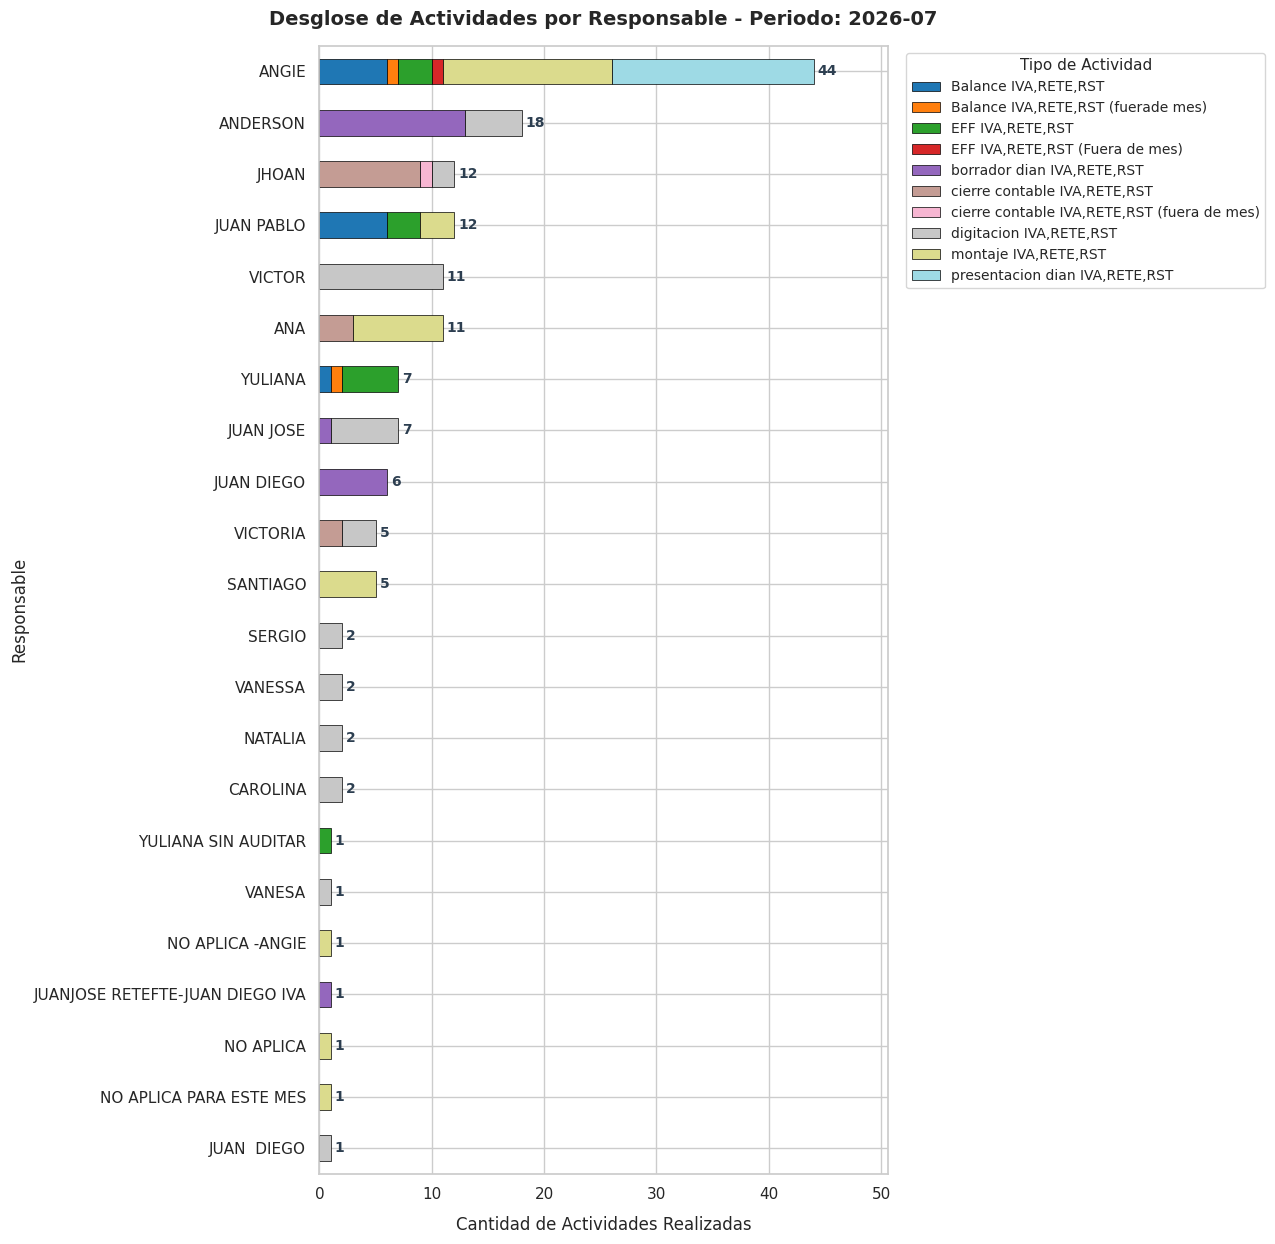

In [73]:
# =========================================================
# 7. GRÁFICO SÓLO DEL MES ACTUAL CON DESGLOSE DE ACTIVIDAD
# =========================================================
import matplotlib.cm as cm

columna_responsable = 'RESPONSABLE'  # Mapea tu columna de responsables
columna_actividad = 'tipo_cambio'  # <- CAMBIA AQUÍ por la columna que describe la actividad (ej. 'operacion', 'tipo_tarea')

if columna_responsable in df_tareas.columns and columna_actividad in df_tareas.columns:

    # 1. Normalización de nombres y actividades
    df_tareas[columna_responsable] = df_tareas[columna_responsable].astype(str).str.strip().str.upper()
    df_tareas[columna_actividad] = df_tareas[columna_actividad].astype(str).str.strip()

    # 2. Asegurar campo año_mes y obtener el último mes disponible
    df_tareas['año_mes'] = df_tareas['fecha_modificacion'].dt.to_period('M').astype(str)
    ultimo_mes = df_tareas['año_mes'].max()

    # 3. Filtrar el dataset únicamente para el mes actual
    df_mes_actual = df_tareas[df_tareas['año_mes'] == ultimo_mes]

    # 4. Crear tabla cruzada (Responsable vs Actividad) y calcular el total para ordenar
    # Esto cuenta cuántas tareas de cada tipo hizo cada responsable
    df_pivot = pd.crosstab(df_mes_actual[columna_responsable], df_mes_actual[columna_actividad])

    # Calcular totales por responsable para ordenar de menor a mayor (el mayor queda arriba)
    df_pivot['Total'] = df_pivot.sum(axis=1)
    df_pivot = df_pivot.sort_values(by='Total', ascending=True)

    # Extraer los totales y eliminar la columna temporal para graficar solo las actividades
    totales_ordenados = df_pivot['Total'].values
    df_pivot = df_pivot.drop(columns=['Total'])

    if not df_pivot.empty:
        # 5. Inicializar el lienzo
        num_elementos = len(df_pivot)
        plt.figure(figsize=(13, 6 + (num_elementos * 0.3))) # El alto se adapta dinámicamente
        sns.set_theme(style="whitegrid")

        # 6. Dibujar gráfico de barras horizontales apiladas usando pandas incorporado
        # Usamos una paleta cualitativa ('tab20' o 'viridis') para diferenciar los tipos de actividades
        ax = df_pivot.plot(kind='barh', stacked=True, ax=plt.gca(), cmap='tab20', edgecolor='black', linewidth=0.5)

        # Personalización estética
        plt.title(f'Desglose de Actividades por Responsable - Periodo: {ultimo_mes}', fontsize=14, weight='bold', pad=15)
        plt.xlabel('Cantidad de Actividades Realizadas', fontsize=12, labelpad=10)
        plt.ylabel('Responsable', fontsize=12)

        # Ajustar el límite de X basado en el volumen total para que no se corten las etiquetas
        max_valor = totales_ordenados.max()
        plt.xlim(0, max_valor * 1.15)

        # Añadir las etiquetas con el total general al final de cada barra compuesta
        for idx, total in enumerate(totales_ordenados):
            plt.text(total + (max_valor * 0.008), idx,
                     f'{int(total)}', va='center', ha='left', fontsize=10, weight='bold', color='#2c3e50')

        # Configurar la leyenda para que se muestre fuera del gráfico y no tape las barras
        plt.legend(title='Tipo de Actividad', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10, title_fontsize=11)

        plt.tight_layout()
        plt.show()
    else:
        print(f"\n⚠️ No se encontraron datos para el periodo {ultimo_mes}.")
else:
    print(f"\n⚠️ Asegúrate de que ambas columnas ('{columna_responsable}' y '{columna_actividad}') existan en el dataset.")

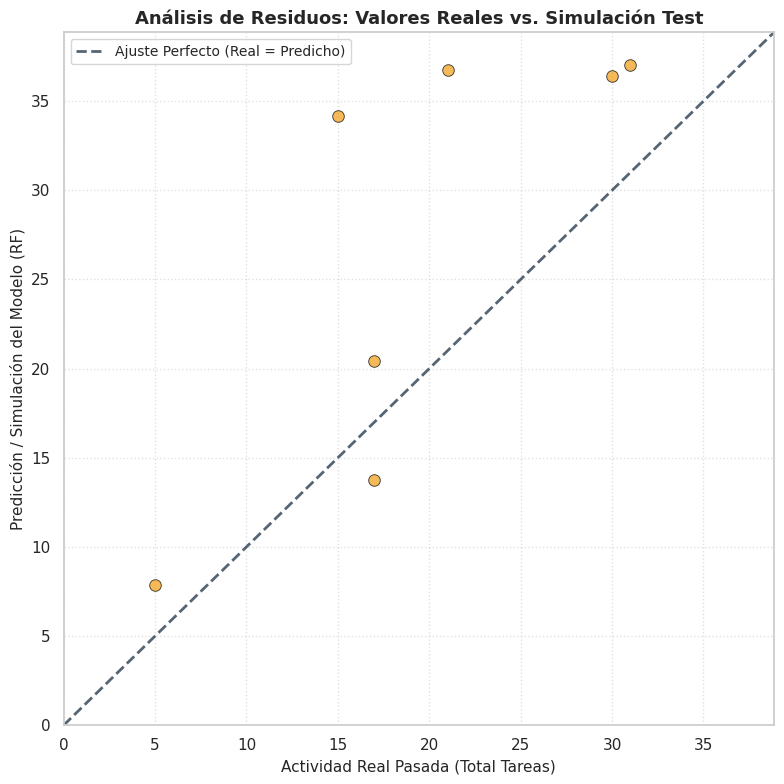

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Filtrar los datos eliminando filas donde no hubo predicción de prueba (igual que en tu gráfica base)
df_evaluacion = serie_temporal.dropna(subset=['prediccion_test'])

plt.figure(figsize=(8, 8))
sns.set_theme(style="whitegrid")

# Gráfico de dispersión cruzando Real vs Predicho
sns.scatterplot(
    x=df_evaluacion['total_tareas'],
    y=df_evaluacion['prediccion_test'],
    alpha=0.7,
    color='#f39c12',
    s=70,
    edgecolor='black'
)

# Línea de referencia ideal de 45 grados (Y = X)
lims = [0, max(df_evaluacion['total_tareas'].max(), df_evaluacion['prediccion_test'].max()) * 1.05]
plt.plot(lims, lims, color='#2c3e50', linestyle='--', alpha=0.8, linewidth=2, label='Ajuste Perfecto (Real = Predicho)')

plt.title('Análisis de Residuos: Valores Reales vs. Simulación Test', fontsize=13, weight='bold')
plt.xlabel('Actividad Real Pasada (Total Tareas)', fontsize=11)
plt.ylabel('Predicción / Simulación del Modelo (RF)', fontsize=11)
plt.xlim(lims)
plt.ylim(lims)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

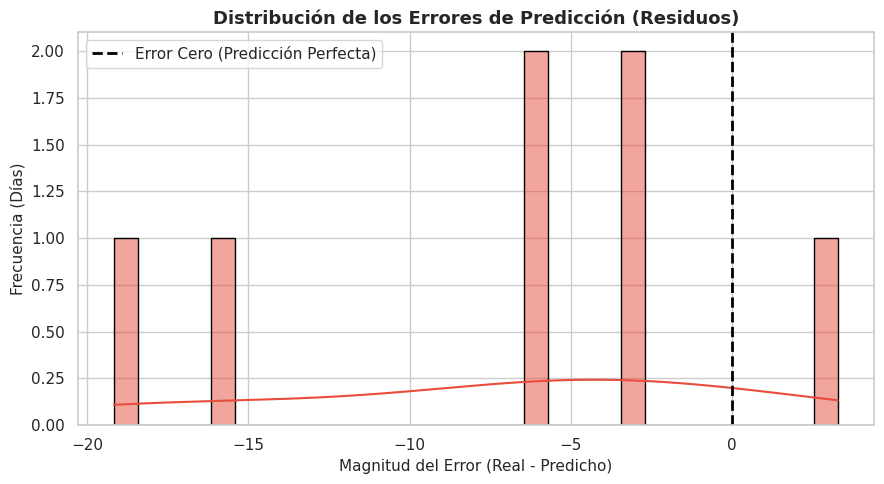

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la diferencia (Residuos) en el set de prueba
df_evaluacion = serie_temporal.dropna(subset=['prediccion_test'])
residuos = df_evaluacion['total_tareas'] - df_evaluacion['prediccion_test']

# 2. Graficar la distribución
plt.figure(figsize=(9, 5))
sns.histplot(residuos, kde=True, color='#e74c3c', bins=30, edgecolor='black')

# Línea en 0 (Predicción perfecta)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Error Cero (Predicción Perfecta)')

plt.title('Distribución de los Errores de Predicción (Residuos)', fontsize=13, weight='bold')
plt.xlabel('Magnitud del Error (Real - Predicho)', fontsize=11)
plt.ylabel('Frecuencia (Días)', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

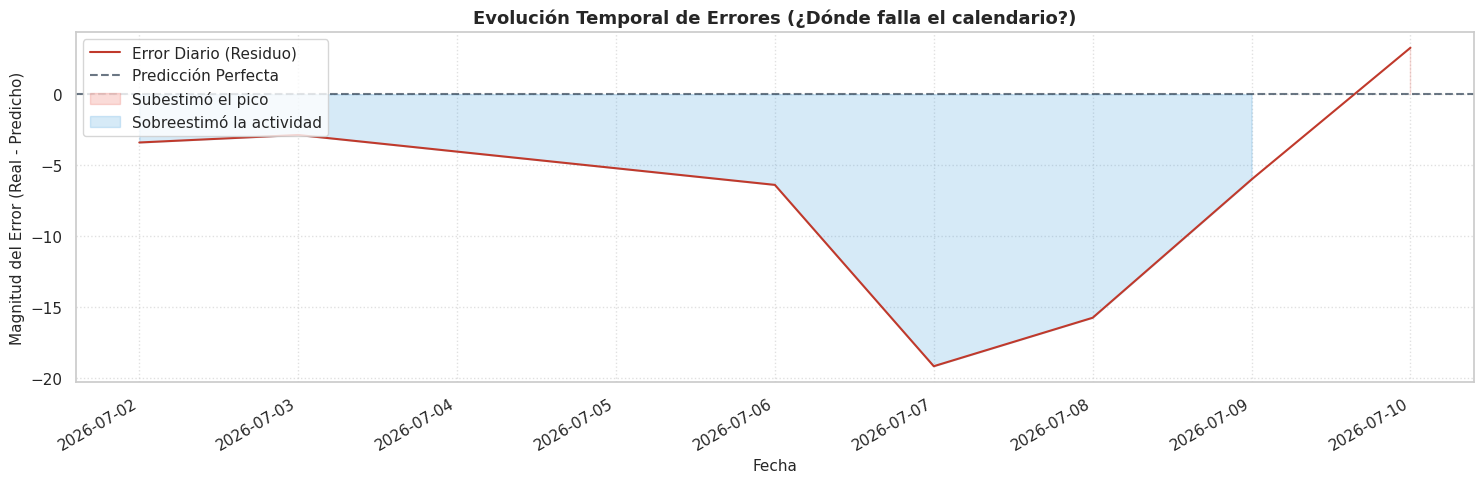

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filtrar filas válidas para la evaluación del test
df_residuos = serie_temporal.dropna(subset=['prediccion_test']).copy()

# 2. Calcular el residuo puro (Real - Predicho)
df_residuos['residuo'] = df_residuos['total_tareas'] - df_residuos['prediccion_test']

# 3. Graficar la evolución temporal del error
plt.figure(figsize=(15, 5))
plt.plot(df_residuos['fecha'], df_residuos['residuo'], color='#c0392b', linewidth=1.5, label='Error Diario (Residuo)')
plt.axhline(y=0, color='#2c3e50', linestyle='--', alpha=0.7, linewidth=1.5, label='Predicción Perfecta')

# Rellenar áreas para diferenciar sobreestimaciones de subestimaciones
plt.fill_between(df_residuos['fecha'], df_residuos['residuo'], 0,
                 where=(df_residuos['residuo'] > 0), color='#e74c3c', alpha=0.2, label='Subestimó el pico')
plt.fill_between(df_residuos['fecha'], df_residuos['residuo'], 0,
                 where=(df_residuos['residuo'] < 0), color='#3498db', alpha=0.2, label='Sobreestimó la actividad')

plt.title('Evolución Temporal de Errores (¿Dónde falla el calendario?)', fontsize=13, weight='bold')
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Magnitud del Error (Real - Predicho)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

#Prediccion acertada
## 24/06/2026

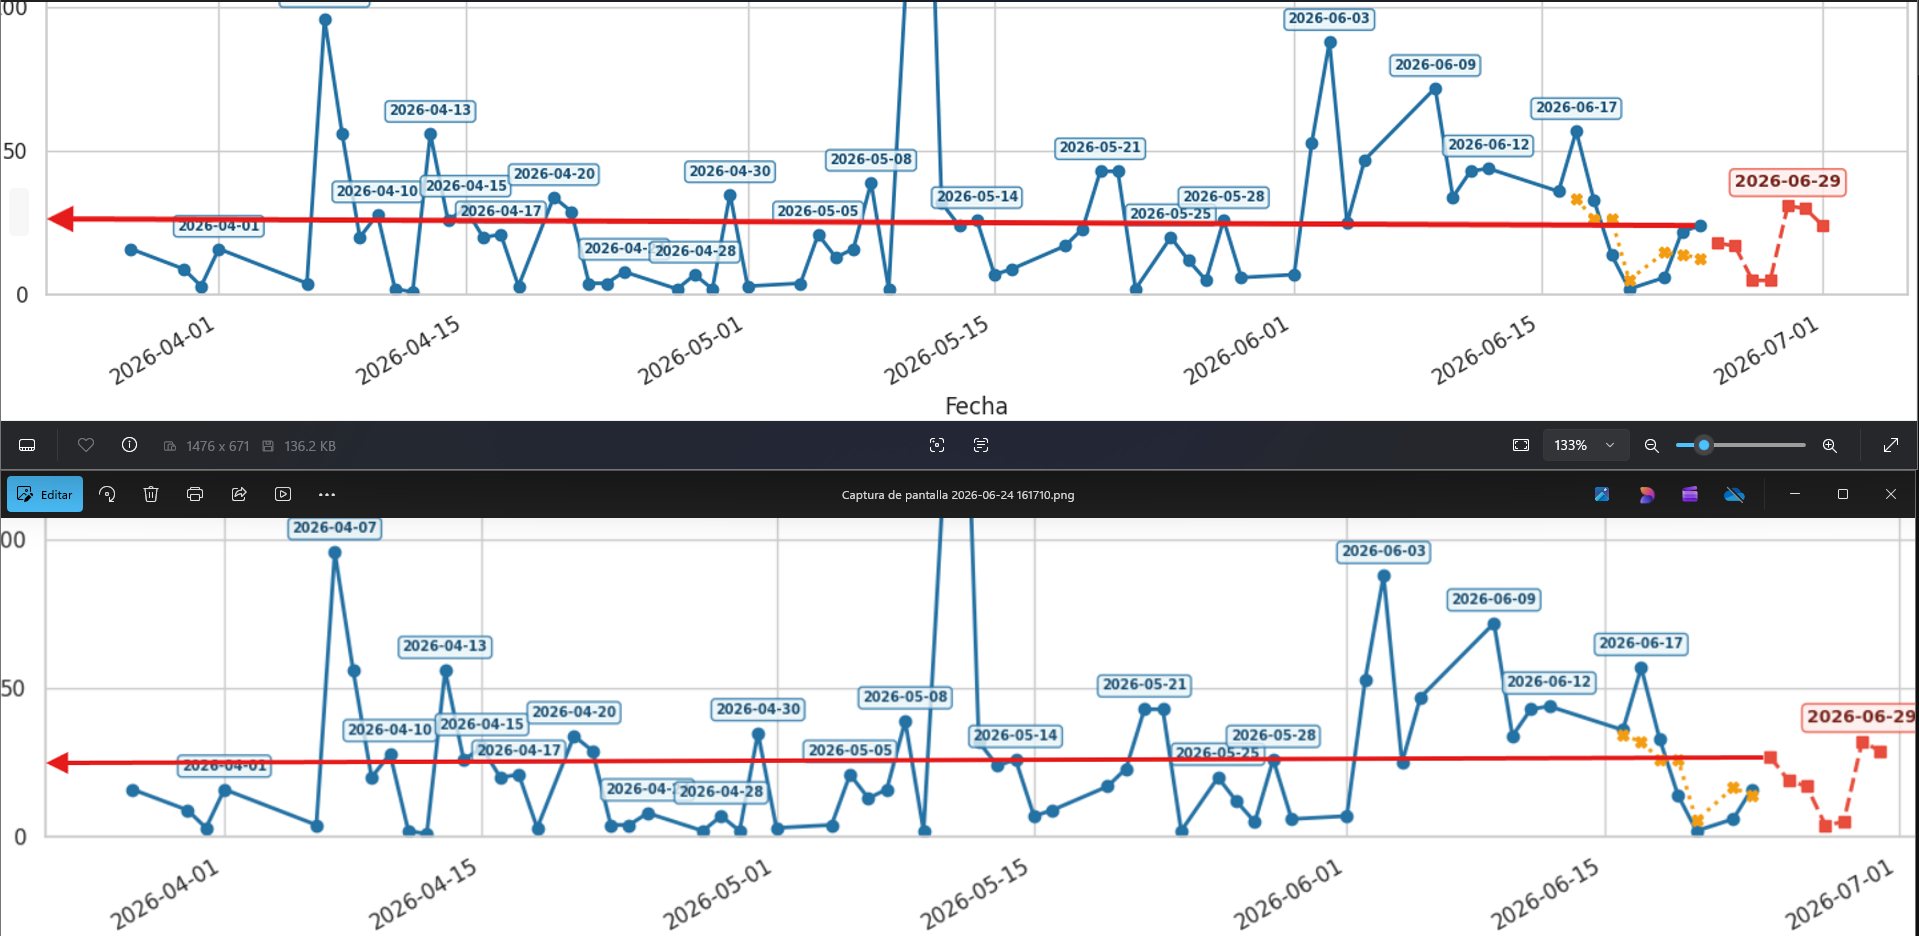

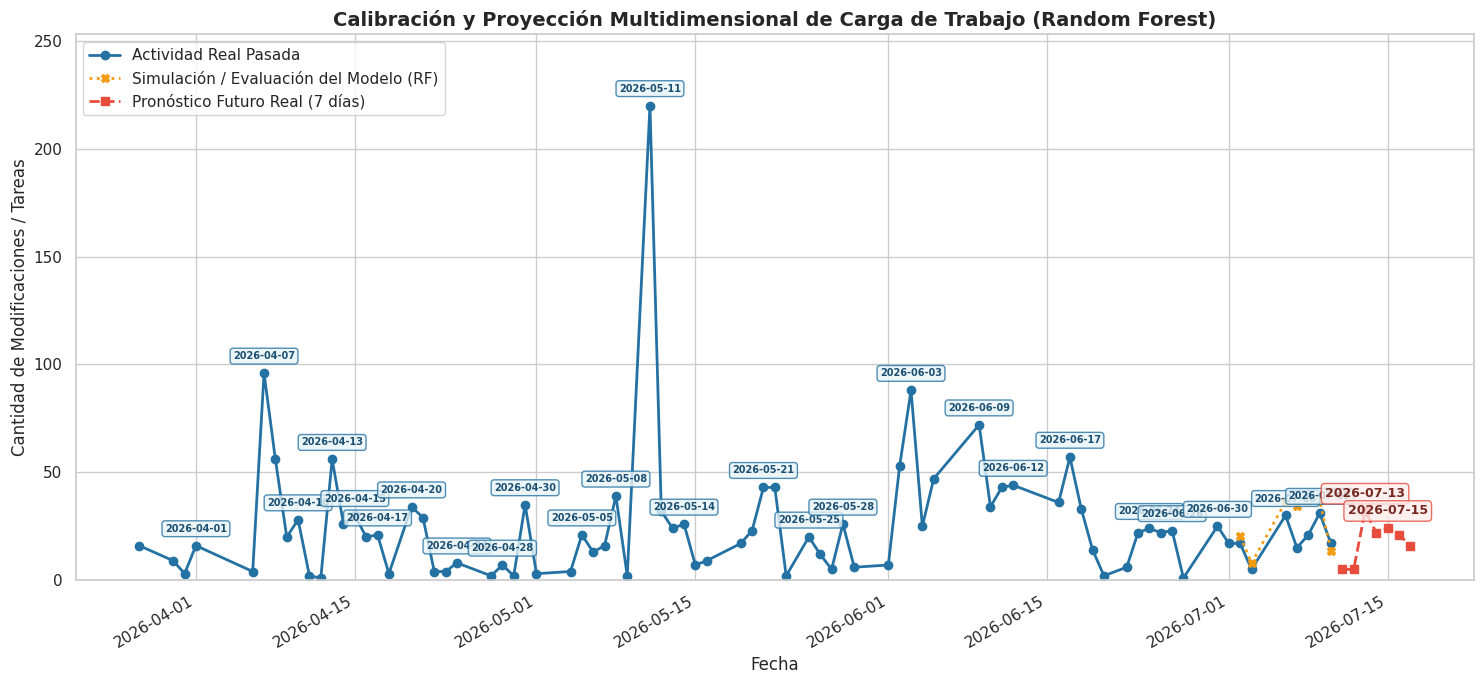

In [78]:
# ==========================================
# 5. GRÁFICA DE TENDENCIA, VALIDACIÓN Y PRONÓSTICO
# ==========================================
plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#2471a3', marker='o', linewidth=2)

if mae is not None:
    df_test_plot = serie_temporal.dropna(subset=['prediccion_test'])
    plt.plot(df_test_plot['fecha'], df_test_plot['prediccion_test'], label='Simulación / Evaluación del Modelo (RF)', color='#f39c12', linestyle=':', marker='X', linewidth=2)

plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Real (7 días)', color='#e74c3c', linestyle='--', marker='s', linewidth=2)

# Etiquetado de Picos
picos_hist, _ = find_peaks(serie_temporal['total_tareas'], distance=2, prominence=1)
for idx in picos_hist:
    fecha_pico = serie_temporal['fecha'].iloc[idx]
    valor_pico = serie_temporal['total_tareas'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=7, weight='bold', color='#1b4f72',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#e8f4f8", ec="#2471a3", lw=1, alpha=0.8))

picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1)
for idx in picos_fut:
    fecha_pico = df_futuro['fecha'].iloc[idx]
    valor_pico = df_futuro['pronostico'].iloc[idx]
    plt.annotate(fecha_pico.strftime('%Y-%m-%d'), xy=(fecha_pico, valor_pico), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, weight='bold', color='#78281f',
                 bbox=dict(boxstyle="round,pad=0.3", fc="#fdedec", ec="#e74c3c", lw=1, alpha=0.8))

plt.title('Calibración y Proyección Multidimensional de Carga de Trabajo (Random Forest)', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=12)
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.15)
plt.gcf().autofmt_xdate()
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()